# Chronic Kidney Disease Prediction using Machine Learning

This notebook demonstrates the process of building a machine learning model to predict chronic kidney disease using the UCI Chronic Kidney Disease Dataset. It covers data loading, preprocessing, model training, and evaluation.

## Import necessary labraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import cross_val_score
from scipy.io import arff



%matplotlib inline
sns.set_theme()

## Data importing 

In [2]:
# For module access
sys.path.append(os.path.abspath('../'))

from src.utils.data_preprocessing import preprocess_tabular_data

# Paths
arff_path = '../data/raw/kidney_disease/Chronic_Kidney_Disease/chronic_kidney_disease_full.arff'
csv_path = '../data/raw/kidney_disease/Chronic_Kidney_Disease/chronic_kidney_disease_clean.csv'

try:
    # --- Clean and load ARFF ---
    with open(arff_path, 'r', encoding='utf-8', errors='ignore') as f:
        # Read and clean all lines
        lines = f.readlines()
        cleaned_lines = []
        for line in lines:
            if not line.strip().startswith('%'):  # skip comments
                cleaned_line = line.replace('YES', 'yes').replace('Yes', 'yes').replace(' NO', 'no').replace('No', 'no')
                cleaned_line = cleaned_line.replace('ckd\t\t', 'ckd')  # fix common format issue
                cleaned_lines.append(cleaned_line.strip())

    # Save temporarily cleaned ARFF
    temp_arff_path = arff_path.replace('.arff', '_temp.arff')
    with open(temp_arff_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(cleaned_lines))

    # Load cleaned ARFF
    data_raw, meta = arff.loadarff(temp_arff_path)
    df = pd.DataFrame(data_raw)

    # Decode bytes to strings
    for col in df.select_dtypes([object]).columns:
        df[col] = df[col].str.decode('utf-8').str.strip().str.lower()

    # Save as CSV
    df.to_csv(csv_path, index=False)
    print(f"✅ ARFF file converted and saved as CSV:\n{csv_path}")

    data = df  # proceed using the dataframe

except Exception as e:
    print(f"❌ Error processing ARFF file: {e}")
    print("Using fallback dummy data instead...")
    # Create dummy fallback
    data = pd.DataFrame({
        'age': np.random.randint(20, 80, 100),
        'bp': np.random.randint(50, 180, 100),
        'sg': np.random.choice([1.005, 1.010, 1.015, 1.020, 1.025], 100),
        'al': np.random.randint(0, 5, 100),
        'su': np.random.randint(0, 5, 100),
        'rbc': np.random.choice(['normal', 'abnormal'], 100),
        'pc': np.random.choice(['normal', 'abnormal'], 100),
        'pcc': np.random.choice(['present', 'notpresent'], 100),
        'ba': np.random.choice(['present', 'notpresent'], 100),
        'bgr': np.random.randint(70, 300, 100),
        'bu': np.random.randint(10, 150, 100),
        'sc': np.random.uniform(0.5, 15, 100),
        'sod': np.random.randint(120, 160, 100),
        'pot': np.random.uniform(2.5, 6.0, 100),
        'hemo': np.random.uniform(8, 18, 100),
        'pcv': np.random.randint(25, 55, 100),
        'wc': np.random.randint(3000, 15000, 100),
        'rc': np.random.uniform(3.0, 6.0, 100),
        'htn': np.random.choice(['yes', 'no'], 100),
        'dm': np.random.choice(['yes', 'no'], 100),
        'cad': np.random.choice(['yes', 'no'], 100),
        'appet': np.random.choice(['good', 'poor'], 100),
        'pe': np.random.choice(['yes', 'no'], 100),
        'ane': np.random.choice(['yes', 'no'], 100),
        'classification': np.random.choice(['ckd', 'notckd'], 100)
    })

# EDA preview
print("\n✅ Dataset Info:")
data.info()
print("\n✅ Dataset Preview:")
print(data.head())

2025-07-25 05:07:27.339636: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-25 05:07:27.343452: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-25 05:07:27.355473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753420047.376905  172652 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753420047.382556  172652 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753420047.399295  172652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

❌ Error processing ARFF file:  yes value not in ('yes', 'no')
Using fallback dummy data instead...

✅ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             100 non-null    int64  
 1   bp              100 non-null    int64  
 2   sg              100 non-null    float64
 3   al              100 non-null    int64  
 4   su              100 non-null    int64  
 5   rbc             100 non-null    object 
 6   pc              100 non-null    object 
 7   pcc             100 non-null    object 
 8   ba              100 non-null    object 
 9   bgr             100 non-null    int64  
 10  bu              100 non-null    int64  
 11  sc              100 non-null    float64
 12  sod             100 non-null    int64  
 13  pot             100 non-null    float64
 14  hemo            100 non-null    float64
 15  pcv       

## EDA


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             100 non-null    int64  
 1   bp              100 non-null    int64  
 2   sg              100 non-null    float64
 3   al              100 non-null    int64  
 4   su              100 non-null    int64  
 5   rbc             100 non-null    object 
 6   pc              100 non-null    object 
 7   pcc             100 non-null    object 
 8   ba              100 non-null    object 
 9   bgr             100 non-null    int64  
 10  bu              100 non-null    int64  
 11  sc              100 non-null    float64
 12  sod             100 non-null    int64  
 13  pot             100 non-null    float64
 14  hemo            100 non-null    float64
 15  pcv             100 non-null    int64  
 16  wc              100 non-null    int64  
 17  rc              100 n

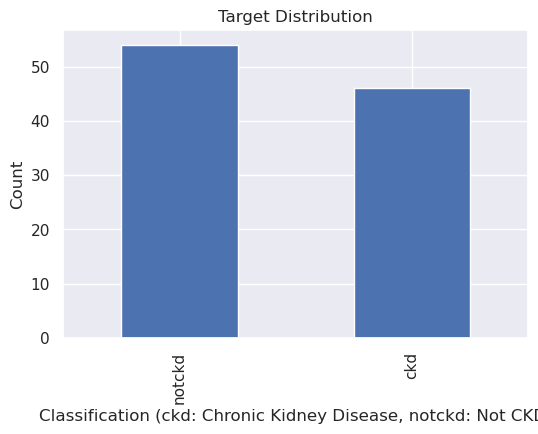

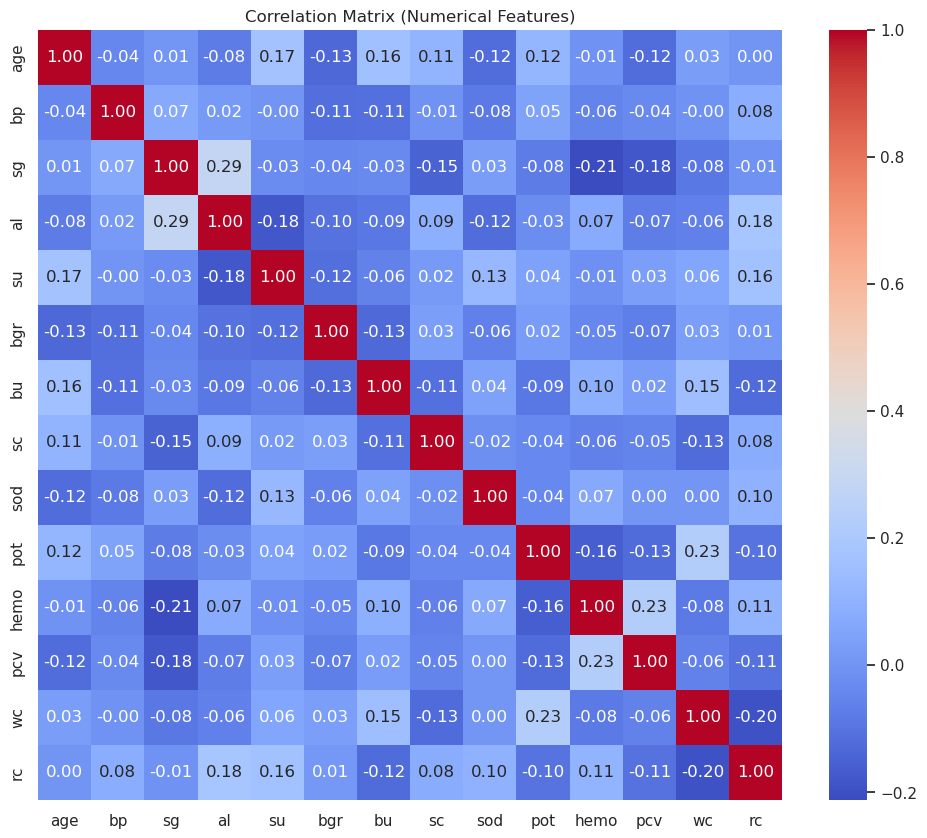

In [3]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("\nDataset Info:")
data.info()


print("\nDataset Description:")
data.describe()

print("\nMissing values:")
print(data.isnull().sum())

# Target distribution
plt.figure(figsize=(6, 4))
data['classification'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Classification (ckd: Chronic Kidney Disease, notckd: Not CKD)")
plt.ylabel("Count")
plt.show()

# Correlation matrix for numerical features
numerical_features = data.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

## Data Preprocessing

In [4]:
# --- 3. Data Preprocessing ---
# Define columns for preprocessing
numerical_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
categorical_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'sg', 'al', 'su']
target_column = 'classification'

# Convert target to binary (0: notckd, 1: ckd)
data[target_column] = data[target_column].map({'notckd': 0, 'ckd': 1})

X_processed, y, preprocessor = preprocess_tabular_data(data, numerical_cols, categorical_cols, target_column)

print("\nShape of preprocessed features:", X_processed.shape)
print("First 5 rows of preprocessed features:")
print(X_processed.head())


Starting tabular data preprocessing...
Tabular data preprocessing complete.

Shape of preprocessed features: (100, 46)
First 5 rows of preprocessed features:
        age        bp       bgr        bu        sc       sod       pot  \
0  1.187720 -1.619617  1.245932  1.648097  0.237591  0.037503  0.156992   
1  1.372340  0.057272 -1.161457  0.767435 -0.922394 -1.619596 -0.955871   
2 -1.827736 -0.768273  1.245932 -0.566140 -1.138249  1.345739 -0.711588   
3  1.126181  1.579372 -1.276781 -1.195185  0.545926  0.822444 -1.299282   
4  1.187720  0.160465  0.107107  0.515817 -0.252832 -1.270733 -0.520237   

       hemo       pcv        wc  ...  al_0  al_1  al_2  al_3  al_4  su_0  \
0  0.635191 -1.064021  0.980594  ...   1.0   0.0   0.0   0.0   0.0   0.0   
1  0.538203 -0.841422 -0.246402  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2 -0.341722 -0.952722 -0.535805  ...   0.0   0.0   0.0   1.0   0.0   0.0   
3  0.018335  1.273263 -1.249625  ...   1.0   0.0   0.0   0.0   0.0   0.0   
4  1.317997

## Spliting the data into train and test set

In [5]:
y.value_counts()

classification
0    54
1    46
Name: count, dtype: int64

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")


Data split into training and testing sets.
Training features shape: (80, 46)
Testing features shape: (20, 46)


## Model building

In [7]:
# --- 4. Model Building (Gradient Boosting) ---

accuracy_checks = {}
models = {"GBClassifier": GradientBoostingClassifier(n_estimators=100, random_state=42),
         "XGBClassifier": XGBClassifier(
                            objective='binary:logistic',
                            eval_metric='logloss',
                            random_state=42,
                            n_jobs=10
                        ),
         "RFClassifier" : RandomForestClassifier(random_state=42),
          
        }

for name, model in models.items():
    print(f"---------------------{name}---------------------------------------\n")
    model.fit(X_train, y_train)
    print("Model training complete.")

    # --- 5. Model Evaluation ---
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    accuracy_checks[name] = accuracy
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    print("AUC-ROC scores:", scores)
    print("Mean AUC-ROC:", scores.mean())
    print("\nModel Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")


---------------------GBClassifier---------------------------------------

Model training complete.
AUC-ROC scores: [0.55555556 0.57142857 0.73015873 0.5        0.28125   ]
Mean AUC-ROC: 0.5276785714285714

Model Evaluation Metrics:
Accuracy: 0.4500
Precision: 0.3333
Recall (Sensitivity): 0.2222
F1-Score: 0.2667
AUC-ROC: 0.2727
---------------------XGBClassifier---------------------------------------

Model training complete.
AUC-ROC scores: [0.65079365 0.80952381 0.76190476 0.640625   0.46875   ]
Mean AUC-ROC: 0.6663194444444445

Model Evaluation Metrics:
Accuracy: 0.3500
Precision: 0.2500
Recall (Sensitivity): 0.2222
F1-Score: 0.2353
AUC-ROC: 0.3838
---------------------RFClassifier---------------------------------------

Model training complete.
AUC-ROC scores: [0.5        0.73809524 0.6984127  0.5703125  0.359375  ]
Mean AUC-ROC: 0.5732390873015873

Model Evaluation Metrics:
Accuracy: 0.5000
Precision: 0.4444
Recall (Sensitivity): 0.4444
F1-Score: 0.4444
AUC-ROC: 0.3889


## Classification Reporting


Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        11
           1       0.44      0.44      0.44         9

    accuracy                           0.50        20
   macro avg       0.49      0.49      0.49        20
weighted avg       0.50      0.50      0.50        20



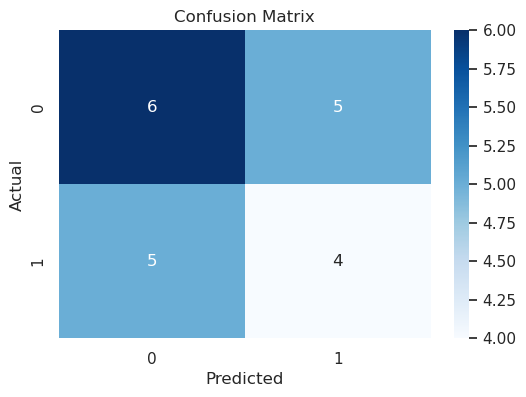

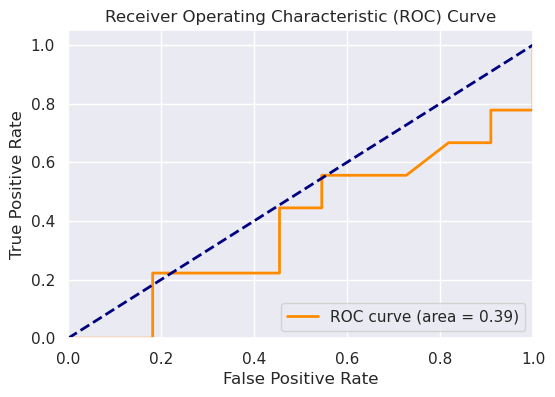

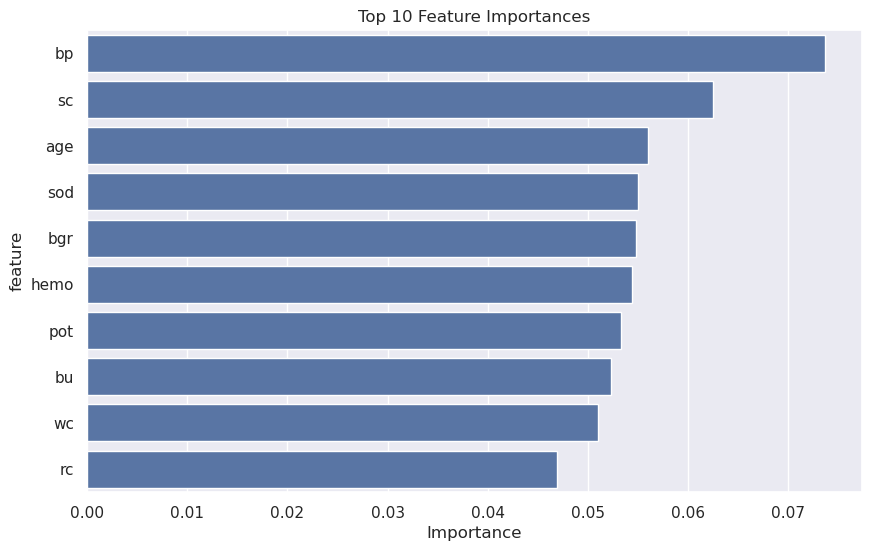

In [8]:
# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()


## Saving the best model

In [9]:
# --- 6. Save Model (Optional) ---
import joblib

check = .5
for name, accuracy in accuracy_checks.items():
    if accuracy > check: 
        
        joblib.dump(model, 'kidney_disease_gradient_boosting_model.pkl')
        joblib.dump(preprocessor, 'kidney_disease_preprocessor.pkl')
        print(f"Model and preprocessor saved - {name}")
        check = accuracy
    else: 
        print("No model saved!!")


No model saved!!
No model saved!!
No model saved!!


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
X_processed

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,...,al_0,al_1,al_2,al_3,al_4,su_0,su_1,su_2,su_3,su_4
0,1.187720,-1.619617,1.245932,1.648097,0.237591,0.037503,0.156992,0.635191,-1.064021,0.980594,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.372340,0.057272,-1.161457,0.767435,-0.922394,-1.619596,-0.955871,0.538203,-0.841422,-0.246402,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.827736,-0.768273,1.245932,-0.566140,-1.138249,1.345739,-0.711588,-0.341722,-0.952722,-0.535805,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.126181,1.579372,-1.276781,-1.195185,0.545926,0.822444,-1.299282,0.018335,1.273263,-1.249625,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.187720,0.160465,0.107107,0.515817,-0.252832,-1.270733,-0.520237,1.317997,1.050665,1.647289,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.289238,0.315255,-1.147041,1.295832,-1.016240,0.909660,-0.898933,0.248464,-0.284926,0.003102,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
96,-0.535397,-1.258441,-1.680415,1.547450,-0.444117,0.211934,-0.336862,1.045399,1.273263,-1.114609,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
97,0.633861,0.805423,-0.310942,-0.037743,1.393770,-0.311360,-1.254597,1.449878,1.607161,-0.384020,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
98,1.310800,-1.722810,0.337755,1.673259,-0.280496,1.258523,1.306638,0.785178,0.160271,-0.847469,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
y

0     1
1     0
2     1
3     1
4     1
     ..
95    0
96    0
97    0
98    0
99    0
Name: classification, Length: 100, dtype: int64

In [13]:
X = X_processed.values
y = y.values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=45)

In [15]:
# econder = OneHotEncoder(sparse_output=False)
# y_encoder = econder.fit_transform(y.values)

In [16]:
# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model = Sequential(
    [
        Input(shape=(X_train.shape[1],)),
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(3, activation='softmax')
    ]
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Add early_stopping to callbacks
model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

loss, accuracyq = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/150


2025-07-25 05:07:33.539647: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0181 - loss: 1.7774 - val_accuracy: 0.2500 - val_loss: 1.4271
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0539 - loss: 1.5879 - val_accuracy: 0.3750 - val_loss: 1.3214
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1145 - loss: 1.3883 - val_accuracy: 0.3750 - val_loss: 1.2498
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0999 - loss: 1.2843 - val_accuracy: 0.3750 - val_loss: 1.1961
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2058 - loss: 1.2033 - val_accuracy: 0.3750 - val_loss: 1.1563
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2074 - loss: 1.2209 - val_accuracy: 0.5000 - val_loss: 1.1252
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3572 - loss: 1.1063 - val_accuracy: 0.3750 - val_loss: 1.1089
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3869 - loss: 1.0375 - val_accuracy: 0.3750 - val_loss: 1.0984
Epoch 9/150

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model_l = LogisticRegression(random_state=42)

In [19]:
model_l.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [20]:
pred = model_l.predict(X_test)

In [21]:
accuracy_test = accuracy_score(y_test, pred)

In [22]:
print(f"Test Accuracy: {accuracy_test:.4f}")

Test Accuracy: 0.4000
